# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [ ]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

In [39]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = 'data/raw'
processed_dir = 'data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at data/raw/outliers_homework.csv. Skipping CSV creation to avoid overwrite.


In [40]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [41]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Apply Detection and Create Flags (choose a numeric column)

In [42]:
from src.outliers import detect_outliers_iqr, detect_outliers_zscore

target_col = 'daily_return' if 'daily_return' in df.columns else df.select_dtypes(include=['number']).columns[0]
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean()  # fraction flagged

outlier_iqr    0.078261
outlier_z      0.043478
dtype: float64

### Visual Checks (boxplot / histogram)

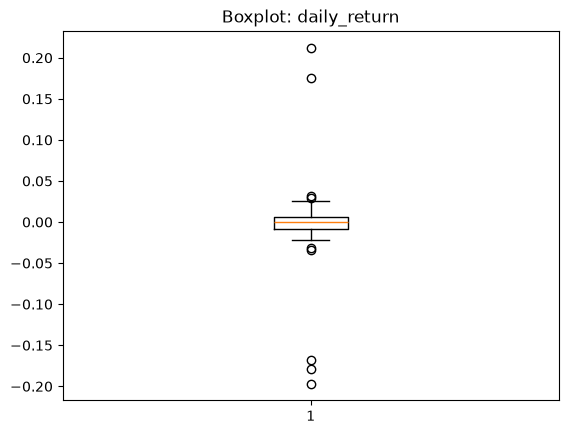

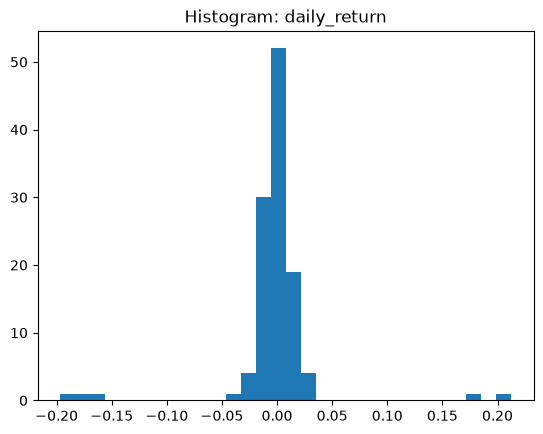

In [43]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [44]:
from src.outliers import winsorize_series

# Option A: summary stats of daily_return under three outlier treatments
summ_all      = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_iqr'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w        = winsorize_series(df[target_col]).describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
comp = pd.concat({'all': summ_all, 'filtered_iqr': summ_filtered, 'winsorized': summ_w}, axis=1)
comp

,all,filtered_iqr,winsorized
mean,-0.001434,-0.000039,-0.000251
median,-0.000187,-0.000100,-0.000187
std,0.040579,0.009443,0.010623


In [45]:
# Option B: Simple regression - did removing the outliers give us a BETTER model?
# The dataset has two correlated numeric columns, so regress one on the other.
resp_col = [c for c in df.columns
            if c != target_col and c != 'date' and not str(c).startswith('outlier_')][0]
print('regressing %s on %s' % (resp_col, target_col))

keep = ~df['outlier_iqr']            # the IQR flag from the cell above
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()

model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_iqr'])

# Read the r2 column before you conclude that removing outliers helped.
results

regressing daily_return_2 on daily_return


,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
filtered_iqr,0.589679,-0.000049,0.573566,0.003851


## Sensitivity plots

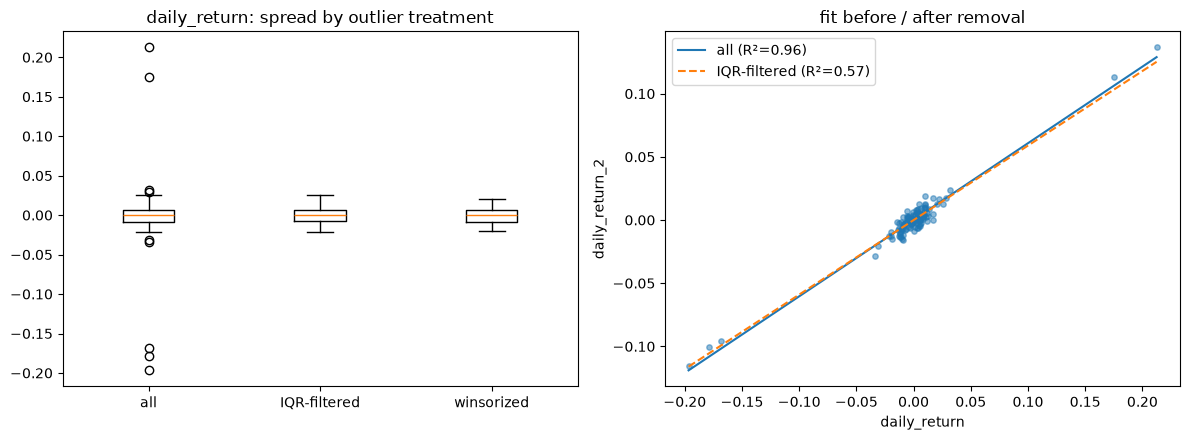

In [46]:
# --- Sensitivity plots ---------------------------------------------------------
w = winsorize_series(df[target_col])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (1) before / after: what each treatment does to the spread of daily_return
axes[0].boxplot([df[target_col], df.loc[~df['outlier_iqr'], target_col], w],
                tick_labels=['all', 'IQR-filtered', 'winsorized'])
axes[0].set_title(f'{target_col}: spread by outlier treatment')

# (2) the two regression fits on one scatter — slope barely moves, R² does
xs = np.linspace(df[target_col].min(), df[target_col].max(), 100).reshape(-1, 1)
axes[1].scatter(df[target_col], df[resp_col], s=15, alpha=0.5)
axes[1].plot(xs, model_all.predict(xs),
             label=f'all (R²={model_all.score(X_all, y_all):.2f})')
axes[1].plot(xs, model_flt.predict(xs), ls='--',
             label=f'IQR-filtered (R²={model_flt.score(X_filtered, y_filtered):.2f})')
axes[1].set(xlabel=target_col, ylabel=resp_col, title='fit before / after removal')
axes[1].legend()
plt.tight_layout(); plt.show()

## Reflection — Outlier Detection & Sensitivity

**Dataset.** Synthetic `data/raw/outliers_homework.csv`: ~115 business-day rows,
`daily_return ~ N(0, 0.01)` (shifted down 0.0015 before May), **5 shock values injected
in May** (±0.17 to ±0.21), and `daily_return_2 = 0.6 · daily_return + N(0, 0.005)`.
No missing values (that was Stage 06). Detection runs on `daily_return`.

**Methods and thresholds.**
- *IQR fence, k = 1.5* (Tukey's default): flags **7.8%** of rows — the 5 shocks plus
  ~4 borderline days.
- *Z-score, |z| > 3.0*, population σ (`ddof=0`): flags **4.3%** — exactly the 5 injected
  shocks, nothing else.
- *Winsorize at 5th/95th pct* as a keep-but-cap alternative.
Defaults were kept: `daily_return` is genuinely close to normal apart from the injected
points, so there is no labelled "wrong value" column to tune against, and z-score is
well-matched to that shape.

**Assumptions.**
- IQR assumes quartiles summarise the spread; z-score assumes approximate normality —
  both hold here by construction.
- The 5 May shocks are treated as **real events** (a market shock is a true observation,
  not a data-entry error), so the defensible treatments are *flag* or *winsorize*, not
  *delete*.
- NaN is treated as "not an outlier" (the comparisons return `False`); none are present
  in this dataset anyway.
- Regressing `daily_return_2` on `daily_return` tests a model whose form is already
  correct (the two share a linear generating equation) — so this isolates the effect of
  outlier handling, not of misspecification.

**Observed impact.**
| | all | filtered (IQR) | winsorized |
|---|---|---|---|
| std of `daily_return` | 0.0406 | 0.0094 | 0.0106 |
| mean | −0.00143 | −0.00004 | −0.00025 |
| regression slope | 0.606 | 0.590 | — |
| regression R² | **0.962** | **0.574** | — |
| regression MAE | 0.00395 | 0.00385 | — |

Removing the IQR-flagged rows cuts std by ~4× — expected, the 5 shocks carry most of the
variance. In the regression the slope barely moves (0.61 → 0.59, both near the true 0.6),
but **R² collapses from 0.96 to 0.57 while MAE is flat**. That is not "a better model":
the shocks are high-leverage points consistent with the same line, so dropping them
shrinks the spread in `x` and lets the ±0.005 noise dominate the fit. R² only *looks*
different because it is now computed over an easier, lower-variance subset.

**Risks if the assumptions are wrong.**
- If the shocks are genuine (they are), deleting them discards the observations that
  matter most for risk. A volatility / VaR estimate built on the filtered series
  (std 0.0094) understates tail risk by ~4× versus the real series (std 0.0406).
- Reading the filtered R² as "outlier removal improved the model" is backwards here.
- Z-score is fragile under heavier contamination: enough shocks would inflate σ and mask
  themselves — with only 5 of ~115 that did not happen, but it would with 15–20.
- `k = 1.5` and `threshold = 3.0` are conventions, not values tuned to a ground truth.

**Decision.** Flag, don't delete — keep `outlier_iqr` / `outlier_z` as columns and use
winsorizing when a downstream model needs tamer tails. Deletion would only be justified
for a confirmed data error, which none of these are.